# setup: trained an unconditional actor on 2 libero_90 living room scene 1 tasks (all 50 demos)
# also trained a classifier on all 50 demos, that when paired with a better actor (one that was cond. on lang and trained on 25 demos), exhibited best-of-N scaling in these 2 tasks.

## here, we analyze the outputs of this "good" classifier with rollouts from this "bad actor"

In [1]:
import os, sys
# sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
# from evaluation_libero import evaluate
os.chdir('/home/yajatyadav/multitask_reinforcement_learning/multitask_RL')
os.environ['MUJOCO_GL'] = 'egl'
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

os.environ['CUDA_VISIBLE_DEVICES'] = '1'
if 'CUDA_VISIBLE_DEVICES' in os.environ:
    os.environ['EGL_DEVICE_ID'] = os.environ['CUDA_VISIBLE_DEVICES']
    os.environ['MUJOCO_EGL_DEVICE_ID'] = os.environ['CUDA_VISIBLE_DEVICES']

classifier_path = '/home/yajatyadav/multitask_reinforcement_learning/checkpoints/libero_bert_classifier_2task_living_room_scene1_p_drop_state_0.5_2_epoch'
actor_path = '/home/yajatyadav/multitask_reinforcement_learning/multitask_RL/exp/multitask_RL/bcflowactor_unconditional/libero_90-living_room_scene1/bcflowactor_livingroomscene1__alphabet_soup_and_ketchup_NO_LANG_CONDITIONING_50_demos_IMAGE_sd00020260126_113728/params_60000.pkl'
import pickle
import flax
import copy
import jax
import jax.numpy as jnp
from pathlib import Path
import copy, json

In [2]:
import copy
from typing import Any

import flax
import flax.linen as nn
import jax
import jax.numpy as jnp
import ml_collections
import optax
import tqdm
import numpy as np
import math
import random

from utils.encoders import encoder_modules
from utils.flax_utils import ModuleDict, TrainState, nonpytree_field, restore_agent_with_file
import pickle
from utils.networks import MLP
from typing import Sequence


# from envs.libero_utils import get_dataset as get_libero_dataset, make_env as make_libero_env
# from evaluation_libero import evaluate
# from utils.log_utils import get_wandb_video

class TransClassifier_BERT(nn.Module):
    vision_encoder: nn.Module = None    
    layer_norm: bool = True
    p_drop_state: float = 0.5
    embed_dim: int = 128

    def setup(self):
        # Action encoder: action_dim -> 128
        self.action_encoder = MLP((self.embed_dim, self.embed_dim), activate_final=True, layer_norm=self.layer_norm)
        
        # Language encoder: 768 (BERT) -> 128
        self.lang_encoder = MLP((self.embed_dim, self.embed_dim), activate_final=True, layer_norm=self.layer_norm)
        
        # Final classifier: 384 (128*3) -> 128 -> 128 -> 1
        self.classifier = MLP((self.embed_dim, self.embed_dim, 1), activate_final=False, layer_norm=self.layer_norm)
    
    def __call__(self, observations, actions, language_embedding, train=True, rng=None):
        """
        Args:
            observations: (batch, obs_dim)
            actions: (batch, action_dim)
            language_embedding: (batch, 768) - BERT embedding
            train: whether to apply dropout
            rng: random key for dropout
            
        Returns:
            logits: (batch, 1) - scalar logit for P(lang | obs, action)
        """
        assert actions is not None, "Actions must be provided to the classifier"
        assert self.vision_encoder is not None, "Encoder must be provided to the classifier"
        
        # Encode observations -> (batch, 128)
        obs_encoded = self.vision_encoder(observations)

        # Dropout on obs encoding
        if rng is None:
            rng = jax.random.PRNGKey(0)
        mask = jax.random.bernoulli(rng, 1 - self.p_drop_state, shape=(obs_encoded.shape[0], 1))
        obs_encoded = jax.lax.cond(
            train,
            lambda x: mask * x,
            lambda x: x,
            obs_encoded
        )
        
        # Encode actions -> (batch, 128)
        action_encoded = self.action_encoder(actions)
        
        # Encode language -> (batch, 128)
        lang_encoded = self.lang_encoder(language_embedding)
        
        # Concatenate all three -> (batch, 384)
        inputs = jnp.concatenate([obs_encoded, action_encoded, lang_encoded], axis=-1)
        
        # Final classification -> (batch, 1)
        return self.classifier(inputs)

def load_classifier(save_dir):
    """Load classifier from saved directory."""
    save_dir = Path(save_dir)
    
    # Load hyperparameters
    with open(save_dir / 'hparams.json', 'r') as f:
        hparams = json.load(f)
    
    # Load parameters
    with open(save_dir / 'params.pkl', 'rb') as f:
        params = pickle.load(f)
    
    # Recreate model definition
    classifier_def = TransClassifier_BERT(
        vision_encoder=encoder_modules[hparams['encoder']](),
        embed_dim=hparams['embed_dim'],
        layer_norm=hparams['layer_norm'],
        p_drop_state=hparams['p_drop_state'],
    )
    
    networks = {'classifier': classifier_def}
    network_def = ModuleDict(networks)
    network_tx = optax.adam(learning_rate=hparams['lr'])
    network = TrainState.create(network_def, params, tx=network_tx)
    
    return network, hparams

In [4]:
classifier = load_classifier(classifier_path)
classifier, hparams = classifier

In [34]:
rollout_paths = Path('/home/yajatyadav/multitask_reinforcement_learning/multitask_RL/analysis/uncond_bc_actor_living_room_scene1_rollouts__')
rng = jax.random.PRNGKey(0)
task_to_logits = {}
import tqdm
for task in rollout_paths.iterdir():
    print(task.stem)
    trajs = list(task.glob('trajs_*.pkl'))[0]
    renders = list(task.glob('renders_*.pkl'))[0]
    eval_info = list(task.glob('eval_info_*.pkl'))[0]

    # load all
    trajs = pickle.load(open(trajs, 'rb'))
    renders = pickle.load(open(renders, 'rb'))
    eval_info = pickle.load(open(eval_info, 'rb'))

    print(eval_info, len(trajs))

    all_traj_logits = []

    for traj in tqdm.tqdm(trajs):
        num_steps = len(traj['observations'])
        this_traj_logits = []
        
        for i in range(num_steps - 5):
            obs = traj['observations'][i]
            
            # Get actions i, i+1, i+2, i+3, i+4
            actions_window = jnp.stack(traj['actions'][i:i+5], axis=0)  # (5, action_dim)
            batch_actions = actions_window.reshape(-1)  # (5 * action_dim,)
            
            # Add batch dimension to everything
            obs = jax.tree.map(lambda x: x[None, ...], obs)
            batch_actions = batch_actions[None, ...]          # (1, 5 * action_dim)
            lang_embedding = np.array(traj['language_embedding'])[0][None, ...] # (1, embed_dim)
            
            # print some shapes
            # print(obs['agentview_rgb'].shape)
            # print(batch_actions.shape)
            # print(lang_embedding.shape)

            logits = classifier.select('classifier')(
                obs, batch_actions, lang_embedding,
                params=classifier.params,
                train=False,
                rng=rng
            )
            # print(i, logits)
            this_traj_logits.append(logits)
        this_traj_logits = np.array(this_traj_logits)
        all_traj_logits.append(this_traj_logits)

    # all_traj_logits = np.array(all_traj_logits)
    task_to_logits[task.stem] = all_traj_logits

libero_90-LIVING_ROOM_SCENE1_pick_up_the_ketchup_and_put_it_in_the_basket
defaultdict(<class 'list'>, {'success': np.float64(0.7), 'env_id': np.float64(0.0)}) 10


100%|██████████| 10/10 [04:09<00:00, 24.92s/it]


libero_90-LIVING_ROOM_SCENE1_pick_up_the_alphabet_soup_and_put_it_in_the_basket
defaultdict(<class 'list'>, {'success': np.float64(0.2), 'env_id': np.float64(0.0)}) 10


100%|██████████| 10/10 [06:40<00:00, 40.00s/it]


In [ ]:
for task in rollout_paths.iterdir():
    print(task.stem)
    trajs = list(task.glob('trajs_*.pkl'))[0]
    renders = list(task.glob('renders_*.pkl'))[0]
    eval_info = list(task.glob('eval_info_*.pkl'))[0]

    # load all
    trajs = pickle.load(open(trajs, 'rb'))
    renders = pickle.load(open(renders, 'rb'))
    eval_info = pickle.load(open(eval_info, 'rb'))

    print(eval_info, len(trajs))

    all_traj_logits = []

    for traj in tqdm.tqdm(trajs):
        num_steps = len(traj['observations'])
        this_traj_logits = []
        
        for i in range(num_steps - 5):
            obs = traj['observations'][i]
            
            # Get actions i, i+1, i+2, i+3, i+4
            actions_window = jnp.stack(traj['actions'][i:i+5], axis=0)  # (5, action_dim)
            batch_actions = actions_window.reshape(-1)  # (5 * action_dim,)
            
            # Add batch dimension to everything
            obs = jax.tree.map(lambda x: x[None, ...], obs)
            batch_actions = batch_actions[None, ...]          # (1, 5 * action_dim)
            lang_embedding = np.array(traj['language_embedding'])[0][None, ...] # (1, embed_dim)
            
            # print some shapes
            # print(obs['agentview_rgb'].shape)
            # print(batch_actions.shape)
            # print(lang_embedding.shape)

            logits = classifier.select('classifier')(
                obs, batch_actions, lang_embedding,
                params=classifier.params,
                train=False,
                rng=rng
            )
            # print(i, logits)
            this_traj_logits.append(logits)
        this_traj_logits = np.array(this_traj_logits)
        all_traj_logits.append(this_traj_logits)

    # all_traj_logits = np.array(all_traj_logits)
    task_to_logits[task.stem] = all_traj_logits

lengths: [149, 133, 161, 161, 380, 380, 199, 137, 380, 137]


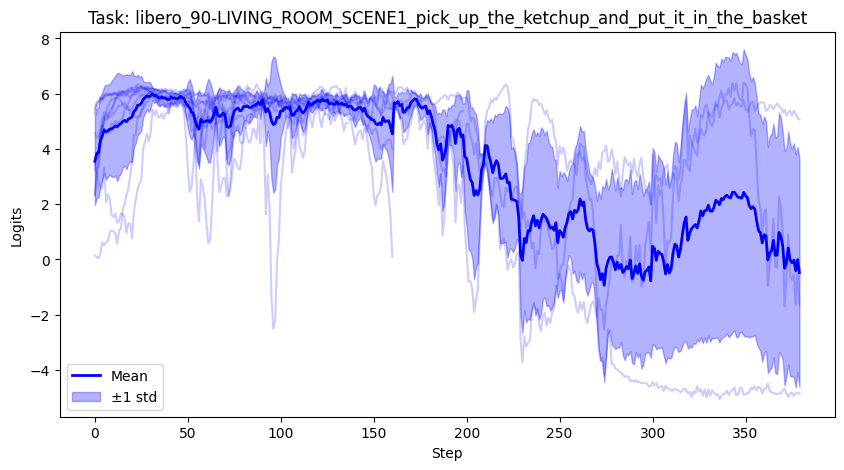

lengths: [380, 380, 380, 135, 129, 380, 380, 380, 380, 380]


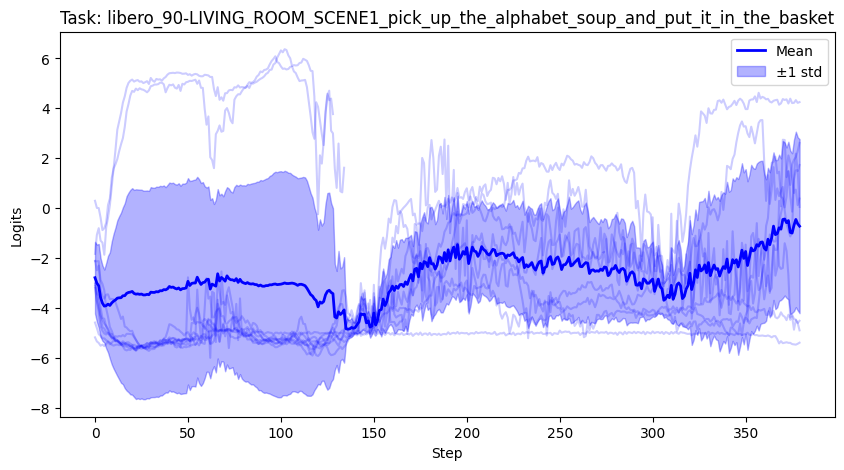

In [44]:
import matplotlib.pyplot as plt
import numpy as np

for task in task_to_logits:
    plt.figure(figsize=(10, 5))
    
    # Extract logits and find max length
    all_logits = [np.array(traj_logits)[:, 0, 0] for traj_logits in task_to_logits[task]]
    lengths = list(len(x) for x in all_logits)
    print(f"lengths: {lengths}")
    max_len = max(lengths)
    
    # Pad with NaN so we can use nanmean/nanstd
    padded = np.full((len(all_logits), max_len), np.nan)
    for i, logits in enumerate(all_logits):
        padded[i, :len(logits)] = logits
    
    # Compute stats (ignoring NaNs)
    mean = np.nanmean(padded, axis=0)
    std = np.nanstd(padded, axis=0)
    
    # Or use min/max for bounds instead of std:
    # lower = np.nanmin(padded, axis=0)
    # upper = np.nanmax(padded, axis=0)
    
    lower = mean - std
    upper = mean + std
    
    x = np.arange(max_len)
    
    # Plot individual trajectories (optional, semi-transparent)
    for logits in all_logits:
        plt.plot(logits, alpha=0.2, color='blue')
    
    # Plot mean and shaded region
    plt.plot(x, mean, color='blue', linewidth=2, label='Mean')
    plt.fill_between(x, lower, upper, alpha=0.3, color='blue', label='±1 std')
    
    plt.xlabel('Step')
    plt.ylabel('Logits')
    plt.title(f"Task: {task}")
    plt.legend()
    plt.show()

# flipping the lang embeddings

In [56]:
flipped_lang_embeddings_map = {}
lang_embeddings = []
for task in rollout_paths.iterdir():
    trajs = list(task.glob('trajs_*.pkl'))[0]
    trajs = pickle.load(open(trajs, 'rb'))
    for traj in trajs:
        for i in range(0, 1):
            lang_embedding = traj['language_embedding'][i]
            print(lang_embedding)
            lang_embeddings.append(lang_embedding)
        break

assert len(lang_embeddings) == 2
flipped_lang_embeddings_map[tuple(lang_embeddings[0])] = lang_embeddings[1]
flipped_lang_embeddings_map[tuple(lang_embeddings[1])] = lang_embeddings[0]
print(f"flipped_lang_embeddings_map: {flipped_lang_embeddings_map}")


# now just reverse the lang embedding when querying the classifier!
rollout_paths = Path('/home/yajatyadav/multitask_reinforcement_learning/multitask_RL/analysis/uncond_bc_actor_living_room_scene1_rollouts__')
rng = jax.random.PRNGKey(0)
task_to_logits = {}
import tqdm
for task in rollout_paths.iterdir():
    print(task.stem)
    trajs = list(task.glob('trajs_*.pkl'))[0]
    renders = list(task.glob('renders_*.pkl'))[0]
    eval_info = list(task.glob('eval_info_*.pkl'))[0]

    # load all
    trajs = pickle.load(open(trajs, 'rb'))
    renders = pickle.load(open(renders, 'rb'))
    eval_info = pickle.load(open(eval_info, 'rb'))

    print(eval_info, len(trajs))

    all_traj_logits = []

    for traj in tqdm.tqdm(trajs):
        num_steps = len(traj['observations'])
        this_traj_logits = []
        
        for i in range(num_steps - 5):
            obs = traj['observations'][i]
            
            # Get actions i, i+1, i+2, i+3, i+4
            actions_window = jnp.stack(traj['actions'][i:i+5], axis=0)  # (5, action_dim)
            batch_actions = actions_window.reshape(-1)  # (5 * action_dim,)
            
            # Add batch dimension to everything
            obs = jax.tree.map(lambda x: x[None, ...], obs)
            batch_actions = batch_actions[None, ...]          # (1, 5 * action_dim)
            lang_embedding = flipped_lang_embeddings_map[tuple(np.array(traj['language_embedding'])[0])][None, ...] # (1, embed_dim)
            
            # print some shapes
            # print(obs['agentview_rgb'].shape)
            # print(batch_actions.shape)
            # print(lang_embedding.shape)

            logits = classifier.select('classifier')(
                obs, batch_actions, lang_embedding,
                params=classifier.params,
                train=False,
                rng=rng
            )
            # print(i, logits)
            this_traj_logits.append(logits)
        this_traj_logits = np.array(this_traj_logits)
        all_traj_logits.append(this_traj_logits)

    # all_traj_logits = np.array(all_traj_logits)
    task_to_logits[task.stem] = all_traj_logits

[-1.83036700e-02  3.89991760e-01 -2.77238518e-01 -8.72186273e-02
 -2.96476632e-01 -1.58208773e-01 -3.41690868e-01  5.65130174e-01
 -3.29167657e-02 -3.36167276e-01 -1.04846999e-01 -4.63040590e-01
  1.10538909e-02  2.13936463e-01 -2.73710731e-02  5.51232547e-02
 -3.95158321e-01  3.22620809e-01  3.36609453e-01  2.05218479e-01
 -1.91464245e-01 -3.74115765e-01  1.01108573e-01 -1.87084690e-01
  2.60093778e-01  2.22535208e-01 -3.86487357e-02 -9.57064033e-02
  3.08841646e-01 -2.57880419e-01 -6.74977340e-03  4.28489953e-01
 -1.12464920e-01 -3.84208471e-01  6.81152940e-01  8.72194469e-02
  9.48607862e-01  1.95931539e-01 -2.44446784e-01  2.18761563e-02
 -4.32886034e-01 -3.38968486e-02  2.68178374e-01 -1.75705597e-01
  7.48467892e-02 -3.15327793e-01 -2.08712649e+00 -7.67522026e-03
 -4.81817238e-02 -5.75473964e-01 -8.49454291e-03 -1.19759634e-01
  3.77008915e-01  4.20185745e-01 -4.00522798e-02  8.48166168e-01
 -3.58242802e-02  7.03347743e-01  2.34392375e-01  1.59723625e-01
 -2.48507112e-01  1.97430

100%|██████████| 10/10 [03:29<00:00, 20.95s/it]


libero_90-LIVING_ROOM_SCENE1_pick_up_the_alphabet_soup_and_put_it_in_the_basket
defaultdict(<class 'list'>, {'success': np.float64(0.2), 'env_id': np.float64(0.0)}) 10


100%|██████████| 10/10 [05:14<00:00, 31.44s/it]


lengths: [149, 133, 161, 161, 380, 380, 199, 137, 380, 137]


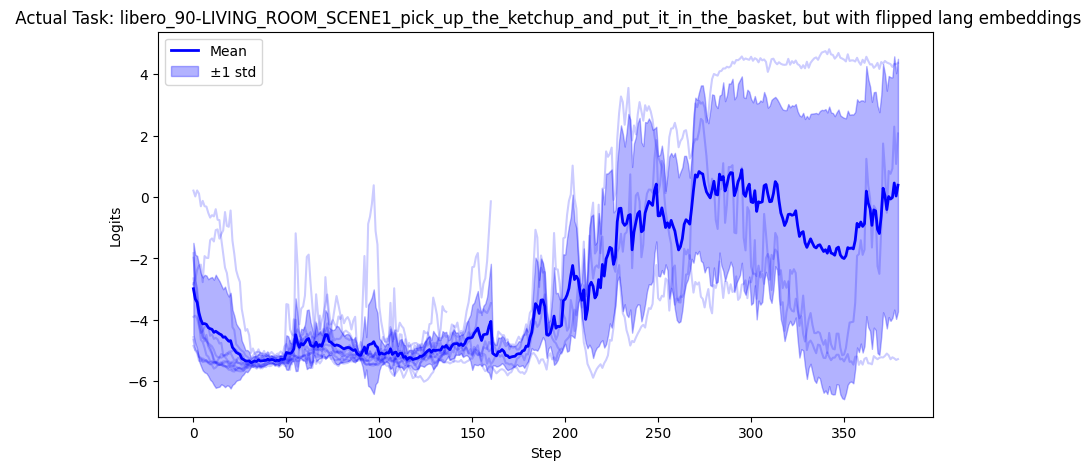

lengths: [380, 380, 380, 135, 129, 380, 380, 380, 380, 380]


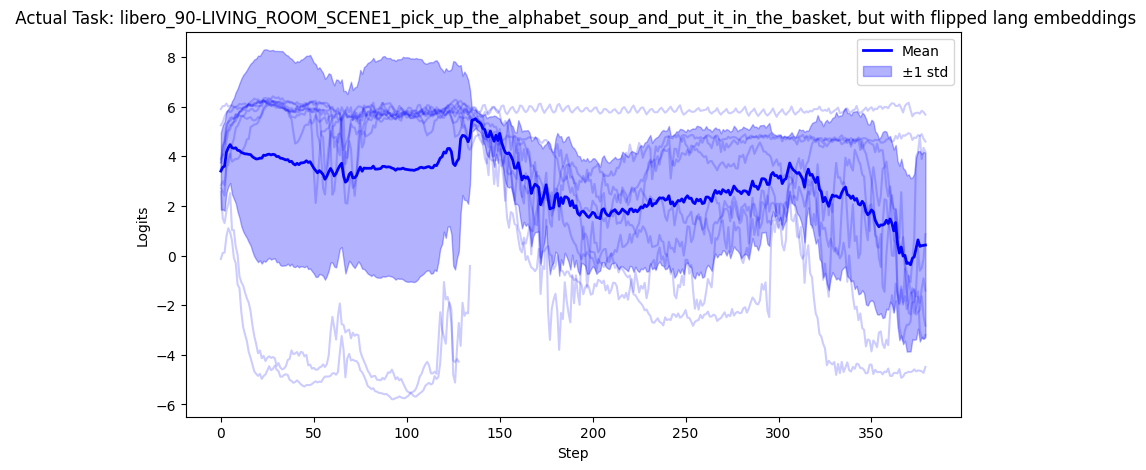

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

for task in task_to_logits:
    plt.figure(figsize=(10, 5))
    
    # Extract logits and find max length
    all_logits = [np.array(traj_logits)[:, 0, 0] for traj_logits in task_to_logits[task]]
    lengths = list(len(x) for x in all_logits)
    print(f"lengths: {lengths}")
    max_len = max(lengths)
    
    # Pad with NaN so we can use nanmean/nanstd
    padded = np.full((len(all_logits), max_len), np.nan)
    for i, logits in enumerate(all_logits):
        padded[i, :len(logits)] = logits
    
    # Compute stats (ignoring NaNs)
    mean = np.nanmean(padded, axis=0)
    std = np.nanstd(padded, axis=0)
    
    # Or use min/max for bounds instead of std:
    # lower = np.nanmin(padded, axis=0)
    # upper = np.nanmax(padded, axis=0)
    
    lower = mean - std
    upper = mean + std
    
    x = np.arange(max_len)
    
    # Plot individual trajectories (optional, semi-transparent)
    for logits in all_logits:
        plt.plot(logits, alpha=0.2, color='blue')
    
    # Plot mean and shaded region
    plt.plot(x, mean, color='blue', linewidth=2, label='Mean')
    plt.fill_between(x, lower, upper, alpha=0.3, color='blue', label='±1 std')
    
    plt.xlabel('Step')
    plt.ylabel('Logits')
    plt.title(f" Actual Task: {task}, but with flipped lang embeddings")
    plt.legend()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

for task in task_to_logits:
    plt.figure(figsize=(10, 5))
    
    # Extract logits and find max length
    all_logits = [np.array(traj_logits)[:, 0, 0] for traj_logits in task_to_logits[task]]
    lengths = list(len(x) for x in all_logits)
    print(f"lengths: {lengths}")
    max_len = max(lengths)
    
    # Pad with NaN so we can use nanmean/nanstd
    padded = np.full((len(all_logits), max_len), np.nan)
    for i, logits in enumerate(all_logits):
        padded[i, :len(logits)] = logits
    
    # Compute stats (ignoring NaNs)
    mean = np.nanmean(padded, axis=0)
    std = np.nanstd(padded, axis=0)
    
    # Or use min/max for bounds instead of std:
    # lower = np.nanmin(padded, axis=0)
    # upper = np.nanmax(padded, axis=0)
    
    lower = mean - std
    upper = mean + std
    
    x = np.arange(max_len)
    
    # Plot individual trajectories (optional, semi-transparent)
    for logits in all_logits:
        plt.plot(logits, alpha=0.2, color='blue')
    
    # Plot mean and shaded region
    plt.plot(x, mean, color='blue', linewidth=2, label='Mean')
    plt.fill_between(x, lower, upper, alpha=0.3, color='blue', label='±1 std')
    
    plt.xlabel('Step')
    plt.ylabel('Logits')
    plt.title(f"Task: {task}")
    plt.legend()
    plt.show()